#Project 2: Linear Regression
Sophia Klymchuk & Devin Zhang

Instructions: <br> Implement a basic linear regression and reproduce figures 3.7 and 3.8. You won't be able to reproduce them exactly since the draws of the observations are random, but it should be close.

Stretch Goal: Read section 3.5, implement the evidence approximation and estimate alpha and beta (i.e. using eqns 3.92 and 3.95). 5 points


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import multivariate_normal

## I. Linear True Relationship
Model: $y = w_0 + w_1x$

### Initiate true relationship and noise

In [ ]:
lower_x_bound, upper_x_bound = -1, 1
true_slope, true_intercept = 0.5, -0.3 # y = 0.5x - 0.3
true_noise_std = 0.2 # This is the noise that gets added when we draw a target observation
true_noise_var = true_noise_std**2
true_noise_beta = 1 / true_noise_var

### Initiate our prior

In [ ]:
mu_0 = np.array([0.0, 0.0]) # initial guesses for [w0, w1]
alpha_0 = 2.0 # single prior precision for both weights
s_0 = (1/alpha_0) * np.eye(2) # prior covariance matrix. assume uncorrelated, single variance

### Start drawing observations and updating

Note that to plot the likelihood for single observation over weight-space:

$P(t_n | w) = N(t_n | w^T \phi(x_n), \beta^{-1}) =
\frac{1}{\sqrt{2\pi\beta^{-1}}} e^{ \frac{-\beta}{2} (t_n - w^T \phi(x_n) )^2} = \frac{1}{\sqrt{2\pi\beta^{-1}}} e^{ \frac{-\beta}{2} (t_n - (w_0\phi_0(x_n) + w_1\phi_1(x_n) )^2 }
= \frac{1}{\sqrt{2\pi\beta^{-1}}} e^{ \frac{-\beta}{2} (t_n - (w_0 + w_1 x_n ))^2 }$

After 1000 iterations, our model is y = -0.30069718879207064 + 0.48266070589208854x


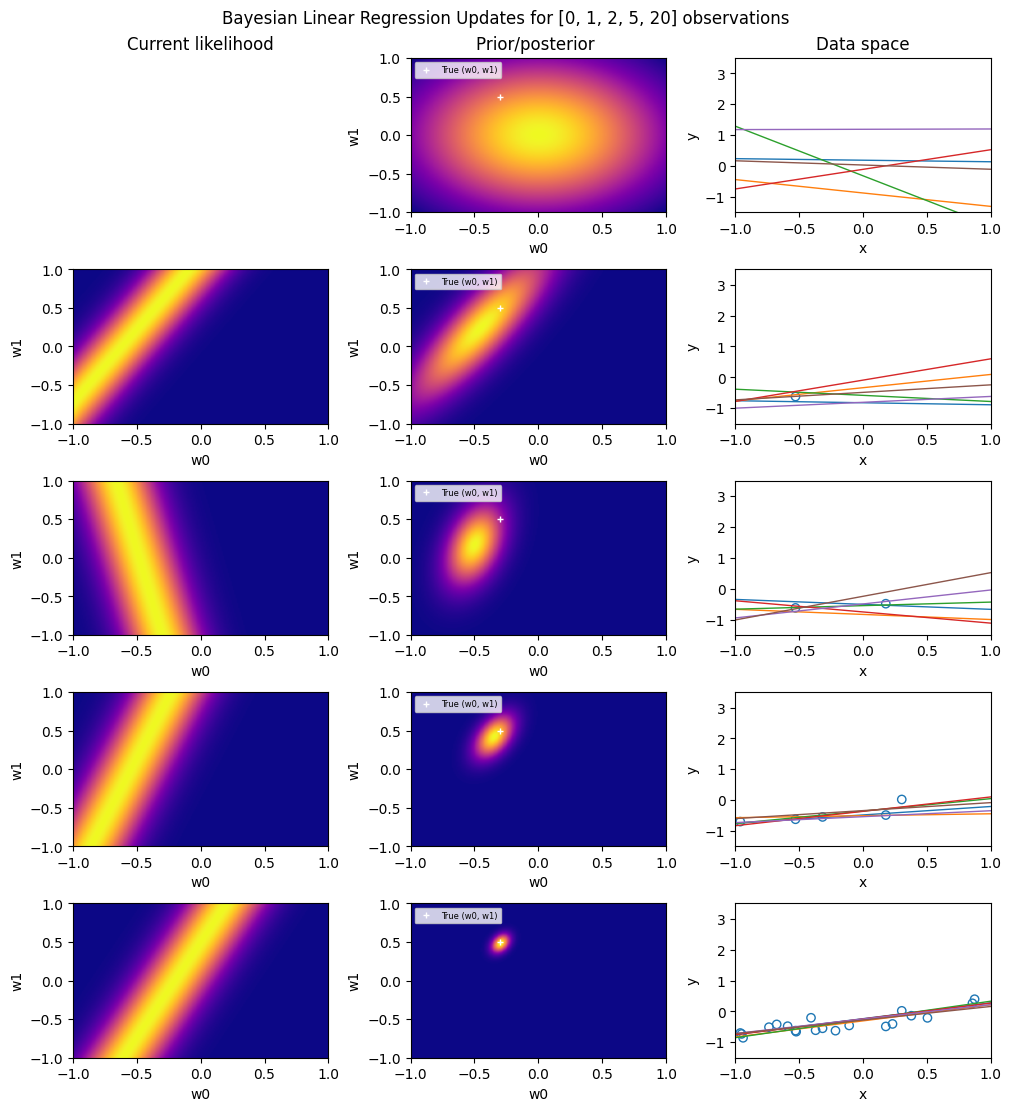

In [ ]:
"""
PLOTTING SETUP STUFF
"""
# Weight-space grid bounds. Chosen for visibility only.
w0_grid = np.linspace(-1.0, 1.0, 200)
w1_grid = np.linspace(-1.0, 1.0, 200)
W0, W1 = np.meshgrid(w0_grid, w1_grid)  # each is shape (G, G)

# Which update steps to visualize (rows of the figure)
steps = [0, 1, 2, 5, 20]

# One row per step; columns: [likelihood of latest obs | prior/posterior | data space]
fig, axes = plt.subplots(len(steps), 3,
                         figsize=(10, 2.2*len(steps)), # width;height per row
                         constrained_layout=True)
fig.suptitle(f"Bayesian Linear Regression Updates for {steps} observations", fontsize=12)
# Column titles at the top
col_titles = ["Current likelihood", "Prior/posterior ", "Data space"]
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12)



"""
INITIALIZATIONS BEFORE LOOP
"""
num_observations = 1000
x_obs_history, t_obs_history = [], [] # store x and target var t
phi_x = []  # Design matrix initialization. Simple linear model. rows: [1, x]

# Current posterior parameters (start at prior)
mu_n, s_n = mu_0.copy(), s_0.copy()

row = 0 # for plotting, since we will have multiple rows of results



"""
START OUR OBSERVATIONS LOOP. OBSERVE, PLOT, CALCULATE, ETC
"""
for n in range(num_observations + 1):

    # Visualization only at selected steps
    if n in steps:

        # LEFT COLUMN: likelihood of the most recent observation in weight space.
        ax = axes[row, 0]
        if n == 0:
            # No data for likelihood yet. Leave blank for the "prior-only" row
            ax.axis('off')
        else:
            xn, tn = x_obs_history[-1], t_obs_history[-1] # Take most recent observations
            resid = tn - (W0 + W1 * xn) # W0 and W1 are the gridded weights (for plotting, not real weight values)
            Likelihood = (2 * np.pi * true_noise_beta**(-1))**(-0.5) * np.exp(-0.5 * true_noise_beta * resid**2)
            ax.imshow(Likelihood,
                      extent=[w0_grid[0], w0_grid[-1], w1_grid[0], w1_grid[-1]],
                      origin='lower', aspect='auto', cmap='plasma')
            ax.set_xlabel("w0"); ax.set_ylabel("w1")

        # MIDDLE COLUMN: prior (n=0) or current posterior (n>0) in weight space.
        ax = axes[row, 1]
        mean = mu_0 if n == 0 else mu_n
        cov  = s_0  if n == 0 else s_n
        mvn = multivariate_normal(mean=mean, cov=cov)
        # Evaluate the 2D Gaussian density at each (w0, w1) grid point
        Posterior = mvn.pdf(np.dstack([W0, W1]))
        ax.imshow(Posterior,
                  extent=[w0_grid[0], w0_grid[-1], w1_grid[0], w1_grid[-1]],
                  origin='lower', aspect='auto', cmap='plasma')
        # Mark the true parameter location for reference
        ax.plot(true_intercept, true_slope, "w+", ms=5, mew=1, label = "True (w0, w1)")
        ax.legend(loc='upper left', fontsize=6)
        ax.set_xlabel("w0"); ax.set_ylabel("w1")

        # Right column: data space (x,y). Sample 6 weights from current prior/posterior
        # to show how predicted lines converge as uncertainty shrinks.
        ax = axes[row, 2]
        x_plot = np.linspace(-1, 1, 200)
        mean_plot = mu_0 if n == 0 else mu_n
        cov_plot  = s_0  if n == 0 else s_n
        W_samples = np.random.multivariate_normal(mean_plot, cov_plot, size=6)
        for w0, w1 in W_samples:
            ax.plot(x_plot, w0 + w1 * x_plot, lw=1)
        if n > 0:
            # Show all observed points so far
            ax.scatter(x_obs_history, t_obs_history, facecolors='none', edgecolors='C0')
        ax.set_xlim(-1, 1); ax.set_ylim(-1.5, 3.5)
        ax.set_xlabel("x"); ax.set_ylabel("y")

        row += 1
        if row == len(steps):
            # Once we reach the number of plots we want, we can break this loop
            break

    if n == num_observations:
        # Exit loop once we reach tot number of observations we want
        break

    # Here we actually do the math to update our distributions per observation

    # Sample an x observ ation
    x_obs = np.random.uniform(lower_x_bound, upper_x_bound)

    # Generate noisy target t = (true_intercept + true_slope * x) + ε
    true_y = true_slope * x_obs + true_intercept
    t_obs = true_y + np.random.normal(0.0, true_noise_std)

    # Append to histories and design matrix
    x_obs_history.append(x_obs)
    t_obs_history.append(t_obs)
    phi_x.append([1.0, x_obs]) # There will only be 2 basis functions per observation: phi_0(x)=1, phi_1(x)=x

    # Convert our lists to arrays for linalg calcs
    Phi = np.asarray(phi_x) # nx2
    t_vec = np.asarray(t_obs_history) # nx1

    # Update our prior parameters to get our posterior
    s_n_inv = np.linalg.inv(s_0) + true_noise_beta * (Phi.T @ Phi) # 2x2
    s_n = np.linalg.inv(s_n_inv) # 2x2
    mu_n = s_n @ (np.linalg.inv(s_0) @ mu_0 + true_noise_beta * Phi.T @ t_vec) #2x1

print(f"After {num_observations} iterations, our model is y = {mu_n[0]} + {mu_n[1]}x")
plt.show()

## II. Sinusoidal True Relationship
Model: 9 Gaussian basis functions

### Initiate true relationship and noise

In [ ]:
lower_x_bound, upper_x_bound = 0, 1
true_freq = 2 * np.pi
true_noise_std = 0.1  # This is the noise that gets added when we draw a target observation. chose kinda randomly.
true_noise_var = true_noise_std**2
true_noise_beta = 1 / true_noise_var

###Basis function helper

In [ ]:
# Basis functions: 9 Gaussian basis functions
# The mu_j are spatial locations of the basis functions
# We will later space them evenly (as in the example in the book)
def phi(x, mu_j, s=0.1):  # s parameter unimportant since these will get scaled by weights later
    return np.exp(-0.5 * ((x - mu_j)/s)**2)

### Initiate prior

In [ ]:
mu_0 = np.zeros(9)  # initial guesses for [w0, w1, ..., w8]
alpha_0 = 2.0       # single prior precision for both weights
s_0 = (1/alpha_0) * np.eye(9)  # prior covariance matrix. assume uncorrelated, single variance

### Start observations loop

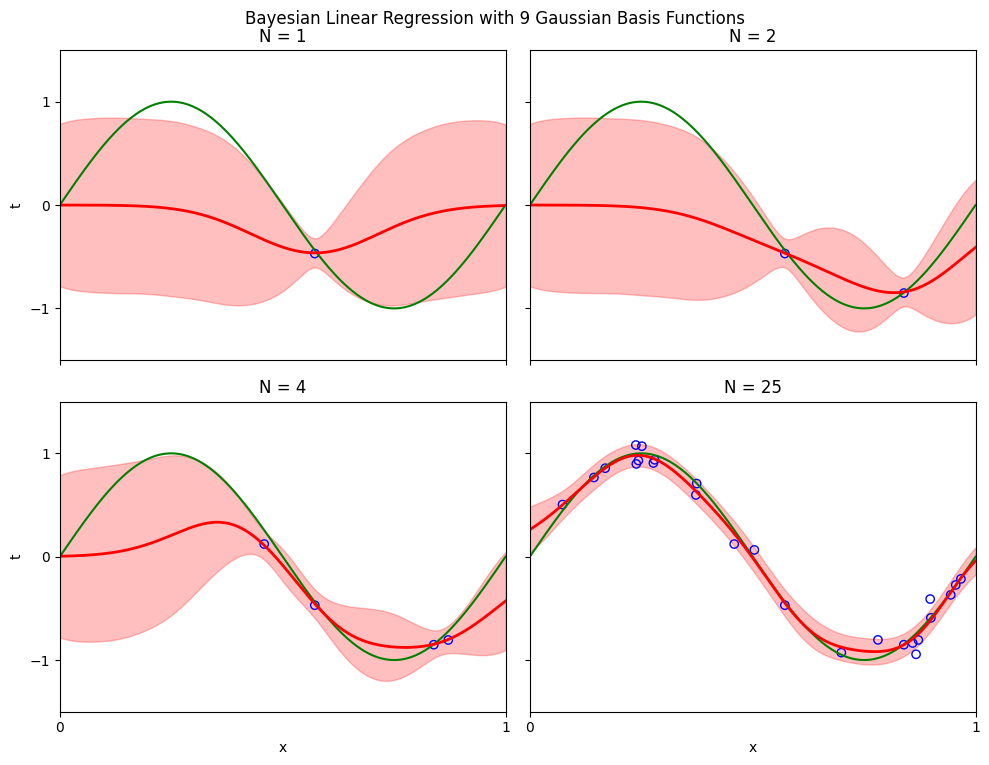

In [ ]:
"""
INITIALIZATIONS BEFORE LOOP
"""
num_observations = 1000
x_obs_history, t_obs_history = [], []  # store x and target var t
phi_x = []  # Design matrix rows for 9 Gaussian basis functions; each row = [phi_1(x), ..., phi_9(x)]

# Fixed basis locations and x-grid for plotting
mu_js = np.linspace(lower_x_bound, upper_x_bound, 9)
x_plot = np.linspace(lower_x_bound, upper_x_bound, 400)

# Current posterior parameters (start at prior)
mu_n, s_n = mu_0.copy(), s_0.copy()

# Figure and which N observations to snapshot
snapshot_Ns = [1, 2, 4, 25]
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

"""
START OUR OBSERVATIONS LOOP. OBSERVE, PLOT, CALCULATE, ETC
"""
for n in range(num_observations):

    # Sample an x observation
    x_obs = np.random.uniform(lower_x_bound, upper_x_bound)

    # Generate noisy target t = sin(frequency * x) + ε
    true_y = np.sin(true_freq * x_obs)
    t_obs = true_y + np.random.normal(0.0, true_noise_std)

    # Append to histories
    x_obs_history.append(x_obs)
    t_obs_history.append(t_obs)

    # Design matrix row for this x
    phi_x.append([phi(x_obs, mu_j) for mu_j in mu_js])

    # Convert our lists to arrays for linalg calcs
    Phi = np.asarray(phi_x)  # nx9
    t_vec = np.asarray(t_obs_history)  # n,

    # Update our prior parameters to get our posterior
    s_n_inv = np.linalg.inv(s_0) + true_noise_beta * (Phi.T @ Phi)  # 9x9
    s_n = np.linalg.inv(s_n_inv)  # 9x9
    mu_n = true_noise_beta * (s_n @ Phi.T @ t_vec)  # 9,

    # Now predictive distribution for plotting on the same grid as the plot
    sigma_n = []
    mean_pred = []
    for xi in x_plot:
        phi_x_n = np.array([phi(xi, mu_j) for mu_j in mu_js])  # 9,
        sigma_n.append(np.sqrt(1/true_noise_beta + phi_x_n.T @ s_n @ phi_x_n))
        mean_pred.append(mu_n.T @ phi_x_n)
    mean_pred = np.asarray(mean_pred).ravel()
    sigma_n = np.asarray(sigma_n).ravel()

    # Get snapshot of progress and plot at N observations
    N_now = len(t_obs_history)
    if N_now in snapshot_Ns:
        ax = axes[snapshot_Ns.index(N_now)]
        # true function
        ax.plot(x_plot, np.sin(true_freq * x_plot), color='green', linewidth=1.5)
        # predictive mean
        ax.plot(x_plot, mean_pred, color='red', linewidth=2)
        # +- 1 SD band
        ax.fill_between(x_plot, mean_pred - sigma_n, mean_pred + sigma_n,
                        color='red', alpha=0.25)
        # observations used so far
        ax.scatter(x_obs_history[:N_now], t_obs_history[:N_now],
                   facecolors='none', edgecolors='blue')

        ax.set_title(f"N = {N_now}")
        ax.set_xlim(lower_x_bound, upper_x_bound)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xticks([0, 1])
        ax.set_yticks([-1, 0, 1])

# labels layout
for ax in axes[2:]:
    ax.set_xlabel("x")
for ax in axes[::2]:
    ax.set_ylabel("t")

fig.suptitle("Bayesian Linear Regression with 9 Gaussian Basis Functions", y=0.95, fontsize=12)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
plt.show()
